
# 🧩 Exploratory Data Analysis (EDA) using NumPy and pandas  
**Dataset:** `WorldEnergy.csv`  

This notebook covers:
1. Loading and inspecting data  
2. Summary statistics  
3. Statistical relationships  
4. Visualisation
5. Anomaly detection using Z-score and IQR methods  
6. Identifying possible causes of anomalies  
7. Data quality checks  
8. Summary and insights


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)


## 1. Load and Inspect Dataset

In [3]:
# Load dataset
df = pd.read_csv('WorldEnergy.csv')

# Filter to latest 10 years only
df['year'] = pd.to_numeric(df['year'], errors='coerce')
latest_year = df['year'].max()
df = df[df['year'] >= latest_year - 9]

print("\nUsing data from year:", latest_year - 9, "to", latest_year)

# Preview dataset
df.head()



Using data from year: 2015 to 2024


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
15,ASEAN (Ember),2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.970,2.202,NaN,595.113,NaN,NaN,NaN,NaN,NaN,321.330,NaN,NaN,NaN,NaN,35.429,NaN,906.970,NaN,906.970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.360,NaN,NaN,81.630,NaN,NaN,NaN,NaN,NaN,377.930,NaN,NaN,NaN,NaN,NaN,41.670,NaN,539.750,NaN,NaN,NaN,NaN,121.480,NaN,13.394,NaN,NaN,NaN,NaN,NaN,166.610,NaN,18.370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,NaN,NaN,NaN,NaN,41.100,NaN,NaN,NaN,NaN,NaN,4.532,NaN,NaN,41.070,21.100,NaN,NaN,NaN,NaN,NaN,4.528,2.326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.610,NaN,18.370,NaN,NaN,NaN,NaN,NaN,2.860,NaN,0.315,NaN,NaN,NaN,NaN,NaN,1.200,NaN,0.132,NaN
16,ASEAN (Ember),2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.070,2.277,NaN,591.490,NaN,NaN,NaN,NaN,NaN,364.560,NaN,NaN,NaN,NaN,37.615,NaN,969.180,NaN,969.180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,774.500,NaN,NaN,79.913,NaN,NaN,NaN,NaN,NaN,379.770,NaN,NaN,NaN,NaN,NaN,39.185,NaN,573.260,NaN,NaN,NaN,NaN,144.150,NaN,14.873,NaN,NaN,NaN,NaN,NaN,194.680,NaN,20.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,NaN,NaN,NaN,NaN,30.170,NaN,NaN,NaN,NaN,NaN,3.113,NaN,NaN,43.800,21.730,NaN,NaN,NaN,NaN,NaN,4.519,2.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,194.680,NaN,20.087,NaN,NaN,NaN,N

In [3]:
# Check structure and data types
df.info()

# Check for missing and duplicated records
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
Index: 2848 entries, 15 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 2.8+ MB

Missing values per column:
country                      0
year                         0
iso_code                   745
population                 634
gdp                       1520
                          ... 
wind_elec_per_capita       762
wind_electricity           432
wind_energy_per_capita    1948
wind_share_elec            440
wind_share_energy         1738
Length: 130, dtype: int64

Duplicated rows: 0


## 2. Summary Statistics

In [4]:

# Descriptive statistics for numeric columns
df.describe()


,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,2848.000,2214.000,1328.000,836.000,1482.000,1184.000,1484.000,2084.000,2204.000,2196.000,1110.000,2192.000,1076.000,1110.000,900.000,1110.000,2071.000,2341.000,680.000,986.000,818.000,986.000,2313.000,1110.000,2202.000,2082.000,2426.000,1100.000,2485.000,2546.000,2151.000,1328.000,1110.000,1110.000,2087.000,2357.000,900.000,1110.000,2329.000,1110.000,1066.000,1110.000,1110.000,2046.000,2316.000,900.000,872.000,1124.000,946.000,1124.000,2288.000,1110.000,2200.000,1020.000,1110.000,1110.000,2092.000,2422.000,900.000,2414.000,1110.000,1110.000,1110.000,1110.000,2096.000,2426.000,900.000,2418.000,1110.000,2082.000,2074.000,507.000,1410.000,1410.000,2096.000,2436.000,1190.000,2386.000,1110.000,1110.000,1110.000,1110.000,2087.000,2357.000,900.000,907.000,1152.000,954.000,1152.000,2329.000,1110.000,1110.000,2410.000,1966.000,988.000,1110.000,2080.000,1846.000,900.000,2402.000,1958.000,1110.000,2096.000,2546.000,1110.000,1110.000,1110.000,2096.000,2475.000,900.000,2418.000,1110.000,1097.000,1110.000,1110.000,2096.000,2426.000,900.000,2418.000,1110.000,1022.000,1110.000,1110.000,2086.000,2416.000,900.000,2408.000,1110.000
mean,2019.275,143165886.481,1428177288688.675,16.655,2.052,185.21

## 3. Statistical Relationship Exploration

In [5]:

# Correlation between numeric features
df.corr(numeric_only=True)


,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
year,1.000,0.020,0.009,-0.042,0.049,0.064,0.039,0.067,0.050,0.048,0.089,-0.093,-0.074,0.108,-0.092,0.005,-0.004,0.024,0.003,0.177,0.198,0.184,-0.010,-0.059,0.036,0.036,0.038,0.084,0.004,0.050,0.023,-0.020,-0.073,0.031,-0.001,0.030,-0.039,0.009,-0.052,-0.099,-0.072,-0.060,0.019,0.043,0.041,-0.013,-0.072,0.018,0.132,0.158,0.049,0.001,0.024,0.024,0.005,0.009,0.016,0.027,-0.010,-0.010,0.002,0.011,0.090,0.048,0.050,0.057,0.023,0.093,0.099,-0.004,0.013,0.015,-0.002,0.002,0.029,0.015,-0.002,0.035,0.008,0.003,0.007,0.005,-0.063,-0.013,-0.028,0.013,0.012,0.179,0.142,-0.121,-0.044,0.050,0.053,0.042,0.007,-0.027,0.023,-0.000,0.006,0.040,0.014,0.043,0.043,0.024,0.001,0.098,0.063,0.045,0.037,0.024,0.084,0.107,-0.050,0.167,0.179,0.305,0.156,0.403,0.330,0.459,0.039,0.056,0.116,0.130,0.107,0.161,0.145,0.181
population,0.020,1.000,0.986,-0.015,0.547,-0.032,0.735,-0.014,0.871,-0.023,-0.036,0.057,0.003,0.247,0.080,0.927,0.136,0.935,0.066,0.319,-0.011,0.916,0.245,0.313,0.930,-0.026,0.930,0.003,0.006,0.614,-0.030,0.015,0.057,0.423,-0.014,0.943,-0.137,0.927,0.018,0.067,0.028,0.615,0.848,-0.022,0.853,-0.110,-0.020,0.433,-0.077,0.825,0.003,-0.097,0.947,-0.019,0.300,0.919,-0.025,0.930,-0.061,-0.042,-0.044,-0

In [6]:
# Covariance matrix
df.cov(numeric_only=True)


,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
year,7.796,37718602.770,193566580800.317,-22.291,1.435,60.384,16.440,41.957,9.961,0.739,0.251,-59.600,-7.933,75.047,-1494.735,112.322,-12.470,92.696,0.163,215.929,11659.898,4602.785,-0.693,-2.709,299.751,510.769,349.971,1.880,0.178,81.168,2051.903,-0.036,-1.331,52.035,-11.885,175.703,-3826.186,525.417,-7.060,-4.528,-3.028,-29.060,300.145,302.469,84.802,-797.716,-20.338,10.826,30701.626,2651.028,5.319,0.080,102.964,1.843,0.798,37.603,150.375,36.588,-350.547,-0.778,0.056,1.397,55.457,532.244,625.534,194.621,1157.686,8.026,4.528,-0.109,1.162,3.493,-0.196,5.654,70.946,15.841,-17.548,1.057,0.148,0.062,6.048,112.950,-309.162,-3.525,-1533.735,8.259,11.831,35055.742,3440.463,-11.911,-1.899,44.019,12.597,1.074,2.410,-1.545,68.774,-0.096,91.730,0.803,0.177,0.420,637.678,1317.899,0.136,55.707,525.061,537.123,92.065,1180.895,6.942,4.380,-104.472,42.538,212.883,157.980,59.118,697.979,4.021,1.954,472.703,11.953,207.744,155.050,64.082,658.154,2.787,1.699
population,37718602.770,475752623563784384.000,5755926161322397401088.000,-3654776954.840,4833690790.220,-9692731737.093,95694071254.588,-2252931523.234,33497193758.830,-92040578.962,-38885636.387,9639722494.414,124063788.280,55079457759.268,474420

## 4. Visualizations

### 4.1 Univariate

<Axes: xlabel='electricity_demand', ylabel='Count'>

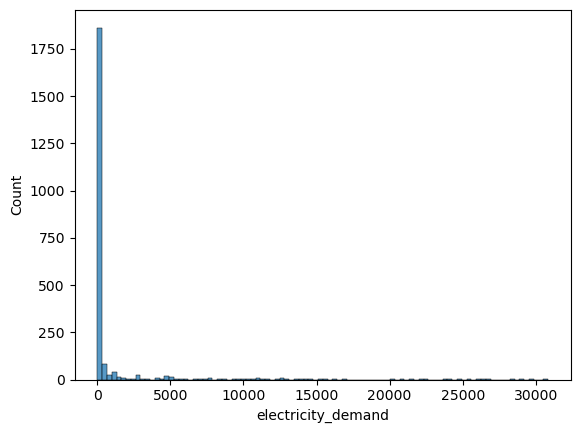

In [7]:
# 1. Histogram of Electricity Demand in 10 Years Duration
sns.histplot(df['electricity_demand'])

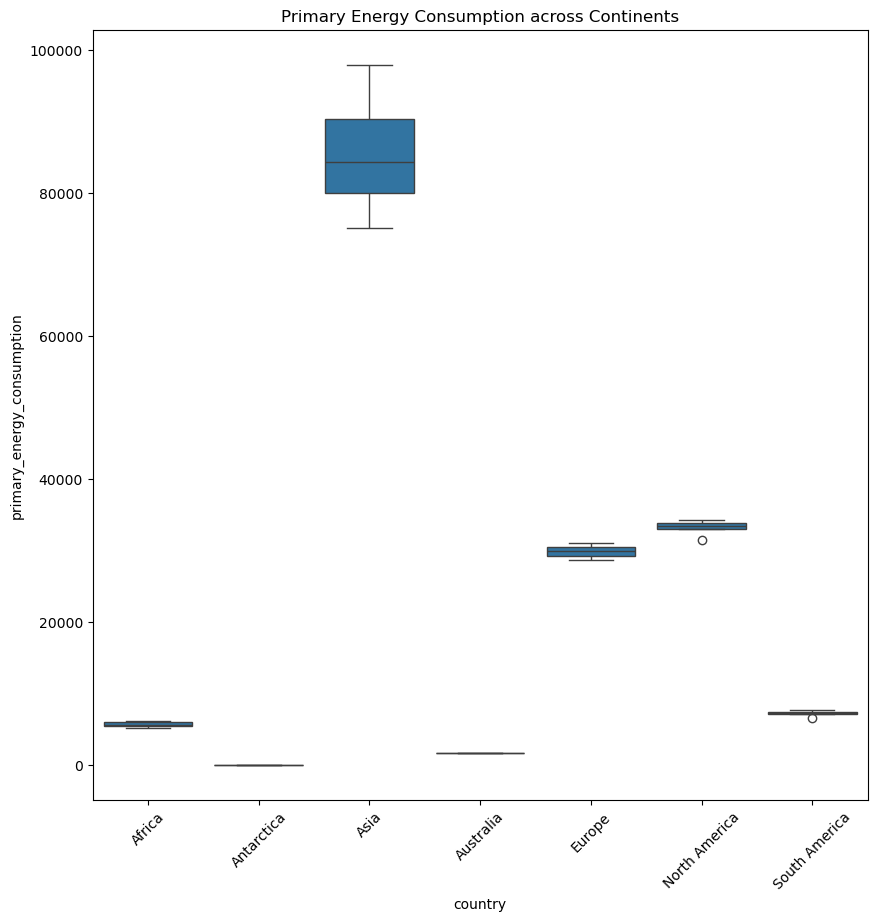

In [4]:
# 2. Boxplot of Primary Energy Consumption across Continents

continents = ['Asia', 'Africa', 'Antarctica', 'Australia', 'Europe', 'North America', 'South America']

cont_df = df[df['country'].isin(continents)]

plt.figure(figsize=(10,10))

sns.boxplot(x='country', y='primary_energy_consumption', data=cont_df)

plt.title('Primary Energy Consumption across Continents')
plt.xticks(rotation=45)

plt.show()

### 4.2 Bivariate

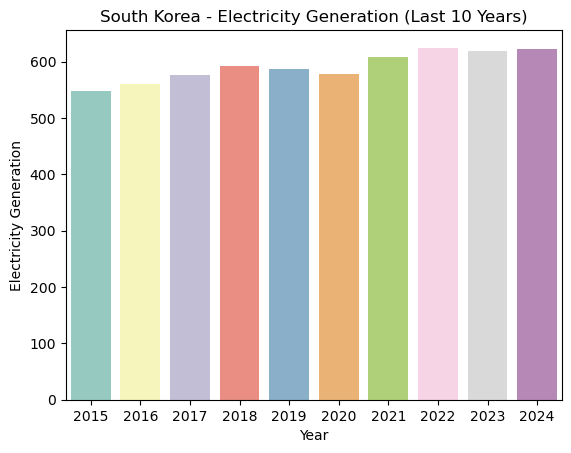

In [9]:
# 1. Barplot for South Korea Electricity Generation within 10 Years

# Filter country
country = 'South Korea'
df_country = df[df['country'] == country]

sns.barplot(x='year', y='electricity_generation', data=df_country, hue='year', palette='Set3', legend=False)

plt.title(f'{country} - Electricity Generation (Last 10 Years)')
plt.xlabel('Year')
plt.ylabel('Electricity Generation')

plt.show()

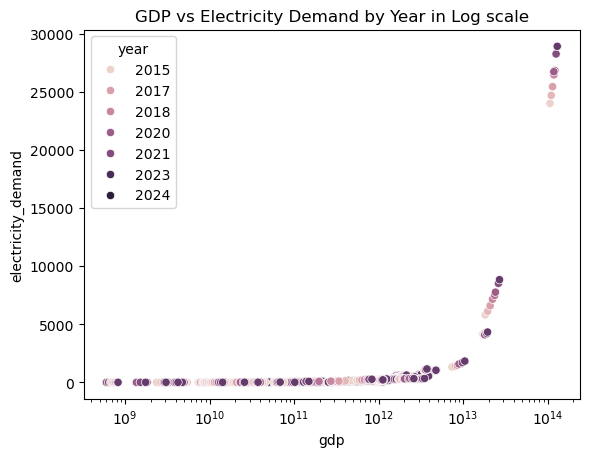

In [10]:
# 2. Scatterplot: GDP vs Electricity Demand
sns.scatterplot(x='gdp', y='electricity_demand', hue='year', data=df)
plt.title('GDP vs Electricity Demand by Year in Log scale')
plt.xscale('log')
plt.show()

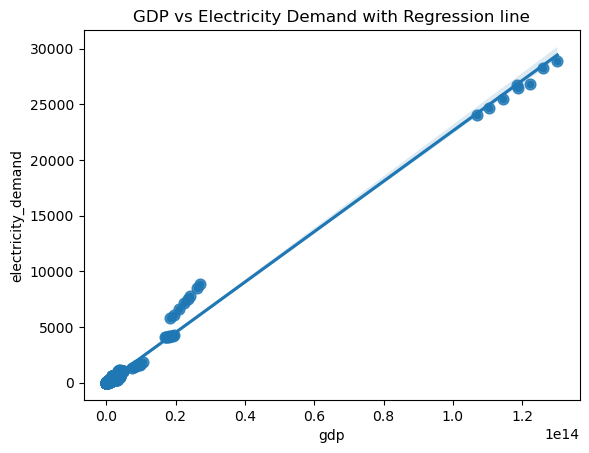

In [11]:
# 3. Scatterplot: GDP vs Electricity Demand with Regression Line
sns.scatterplot(x='gdp', y='electricity_demand', data=df)
plt.title('GDP vs Electricity Demand with Regression line')
sns.regplot(data=df, x='gdp', y='electricity_demand', scatter_kws={'s':60})
plt.show()

### 4.3 Multivariate

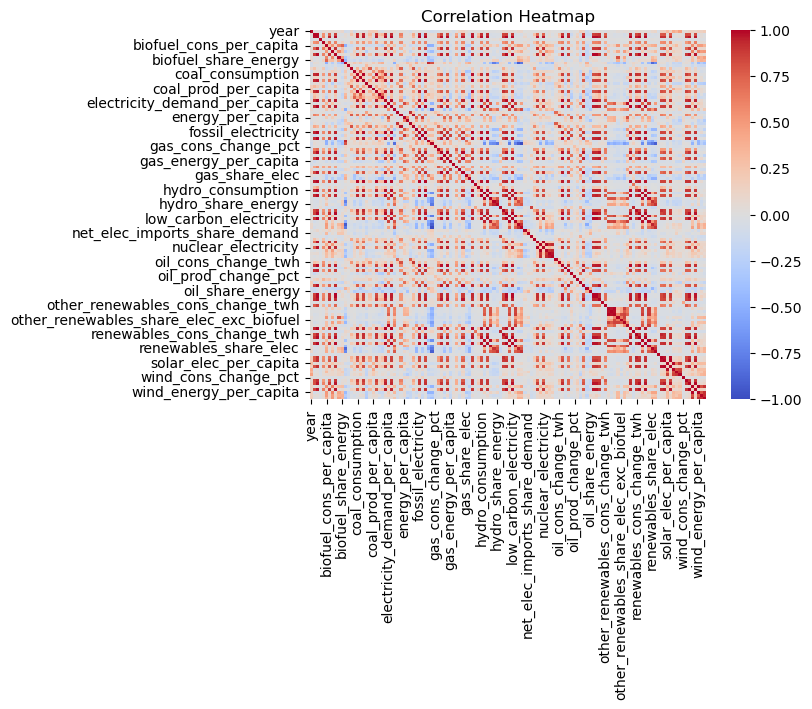

In [12]:
# 1. Overall Correlation Heatmap

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.show()


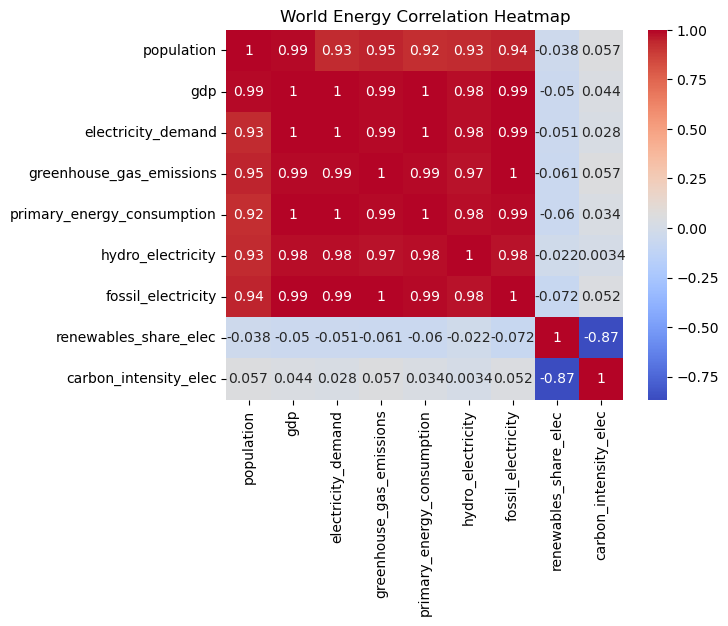

In [13]:
# 2. Focused Correlation Heatmap 

df_renew = df[['population', 'gdp', 'electricity_demand', 'greenhouse_gas_emissions', 'primary_energy_consumption', 'hydro_electricity', 'fossil_electricity', 'renewables_share_elec', 'carbon_intensity_elec']]

plt.figure()

sns.heatmap(df_renew.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("World Energy Correlation Heatmap")
plt.show()

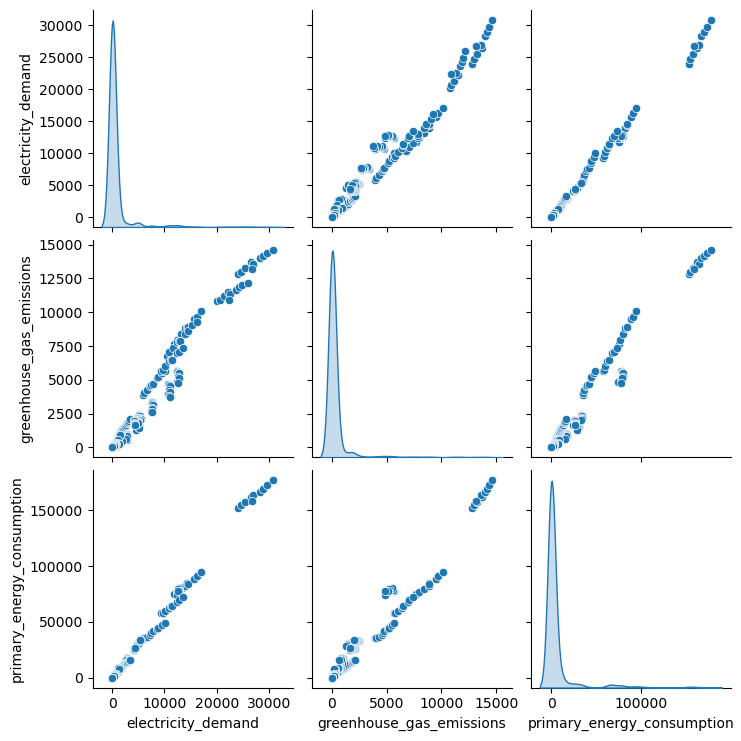

In [14]:
# 3. Pairplot among numeric variables
sns.pairplot(df[['electricity_demand','greenhouse_gas_emissions','primary_energy_consumption']], diag_kind='kde')
plt.show()

## 5. Detecting Anomalies (Outlier Detection)

### Method A: Z-Score Method

In [15]:
mean_power = np.mean(df['renewables_electricity'])
std_power = np.std(df['renewables_electricity'])

# Compute Z-score
df['z_score'] = (df['renewables_electricity'] - mean_power) / std_power

# Flag anomalies
df_anomalies_z = df[np.abs(df['z_score']) > 3]
print("Anomalies detected (Z-Score method):", len(df_anomalies_z))
df_anomalies_z.head()


Anomalies detected (Z-Score method): 68


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy,z_score
1341,Asia,2019,NaN,4651096247.000,NaN,26.821,34.400,34.973,162.661,47.769,222.180,1.549,0.194,619.918,2.366,795.867,7403.922,34436.355,1622.448,7546.160,4.054,1210.373,6679.781,31068.303,52.624,40.986,14340.149,3083.176,14339.771,18.301,2.922,2399.133,18168.764,NaN,1.921,1402.794,2276.167,10586.670,16005.108,74441.297,73.827,88.599,2.523,368.149,14958.739,553.379,2573.820,3216.175,1.969,262.517,2923.417,13597.094,17.949,17.804,8889.479,6.981,290.234,4788.784,416.411,1936.770,1029.603,13.506,5.700,11.733,941.654,9578.987,806.928,3753.100,2059.512,26.173,11.401,0.380,0.003,16.527,223.203,1622.582,140.879,655.240,348.860,4.569,1.931,0.963,238.777,25046.203,100.340,466.690,5385.011,-4.147,-955.365,4747.142,22079.412,3.255,29.810,756.491,255.210,33.030,11.823,79.986,54.871,7.102,162.648,1.780,0.230,0.900,3083.095,84504.664,10.813,718.451,7956.405,666.049,3097.860,1710.651,21.603,9.470,26.491,200.159,974.010,84.111,391.210,209.415,2.728,1.159,10.339,113.672,1274.459,110.656,514.670,274.013,3.589,1.517,3.122
1342,Asia,2020,NaN,4686808823.000,NaN,6.055,9.850,36.808,172.511,53.529,250.880,1.723,0.206,609.475,-0.086,-29.664,7341.177,34406.691,1604.025,7517.760,-0.696,-

### Method B: IQR Method

In [6]:

Q1 = df['renewables_electricity'].quantile(0.25)
Q3 = df['renewables_electricity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_anomalies_iqr = df[(df['renewables_electricity'] < lower_bound) | (df['renewables_electricity'] > upper_bound)]
print("Anomalies detected (IQR method):", len(df_anomalies_iqr))
df_anomalies_iqr.head()


Anomalies detected (IQR method): 439


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,coal_share_energy,electricity_demand,electricity_demand_per_capita,electricity_generation,electricity_share_energy,energy_cons_change_pct,energy_cons_change_twh,energy_per_capita,energy_per_gdp,fossil_cons_change_pct,fossil_cons_change_twh,fossil_elec_per_capita,fossil_electricity,fossil_energy_per_capita,fossil_fuel_consumption,fossil_share_elec,fossil_share_energy,gas_cons_change_pct,gas_cons_change_twh,gas_consumption,gas_elec_per_capita,gas_electricity,gas_energy_per_capita,gas_prod_change_pct,gas_prod_change_twh,gas_prod_per_capita,gas_production,gas_share_elec,gas_share_energy,greenhouse_gas_emissions,hydro_cons_change_pct,hydro_cons_change_twh,hydro_consumption,hydro_elec_per_capita,hydro_electricity,hydro_energy_per_capita,hydro_share_elec,hydro_share_energy,low_carbon_cons_change_pct,low_carbon_cons_change_twh,low_carbon_consumption,low_carbon_elec_per_capita,low_carbon_electricity,low_carbon_energy_per_capita,low_carbon_share_elec,low_carbon_share_energy,net_elec_imports,net_elec_imports_share_demand,nuclear_cons_change_pct,nuclear_cons_change_twh,nuclear_consumption,nuclear_elec_per_capita,nuclear_electricity,nuclear_energy_per_capita,nuclear_share_elec,nuclear_share_energy,oil_cons_change_pct,oil_cons_change_twh,oil_consumption,oil_elec_per_capita,oil_electricity,oil_energy_per_capita,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,oil_share_elec,oil_share_energy,other_renewable_consumption,other_renewable_electricity,other_renewable_exc_biofuel_electricity,other_renewables_cons_change_pct,other_renewables_cons_change_twh,other_renewables_elec_per_capita,other_renewables_elec_per_capita_exc_biofuel,other_renewables_energy_per_capita,other_renewables_share_elec,other_renewables_share_elec_exc_biofuel,other_renewables_share_energy,per_capita_electricity,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
15,ASEAN (Ember),2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.970,2.202,NaN,595.113,NaN,NaN,NaN,NaN,NaN,321.330,NaN,NaN,NaN,NaN,35.429,NaN,906.970,NaN,906.970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.360,NaN,NaN,81.630,NaN,NaN,NaN,NaN,NaN,377.930,NaN,NaN,NaN,NaN,NaN,41.670,NaN,539.750,NaN,NaN,NaN,NaN,121.480,NaN,13.394,NaN,NaN,NaN,NaN,NaN,166.610,NaN,18.370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,NaN,NaN,NaN,NaN,41.100,NaN,NaN,NaN,NaN,NaN,4.532,NaN,NaN,41.070,21.100,NaN,NaN,NaN,NaN,NaN,4.528,2.326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.610,NaN,18.370,NaN,NaN,NaN,NaN,NaN,2.860,NaN,0.315,NaN,NaN,NaN,NaN,NaN,1.200,NaN,0.132,NaN
16,ASEAN (Ember),2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.070,2.277,NaN,591.490,NaN,NaN,NaN,NaN,NaN,364.560,NaN,NaN,NaN,NaN,37.615,NaN,969.180,NaN,969.180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,774.500,NaN,NaN,79.913,NaN,NaN,NaN,NaN,NaN,379.770,NaN,NaN,NaN,NaN,NaN,39.185,NaN,573.260,NaN,NaN,NaN,NaN,144.150,NaN,14.873,NaN,NaN,NaN,NaN,NaN,194.680,NaN,20.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,NaN,NaN,NaN,NaN,30.170,NaN,NaN,NaN,NaN,NaN,3.113,NaN,NaN,43.800,21.730,NaN,NaN,NaN,NaN,NaN,4.519,2.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,194.680,NaN,20.087,NaN,NaN,NaN,N

## 6. Identify Possible Causes of Anomalies

In [17]:

# 1. Count anomalies by country
df_anomalies_iqr['year'].value_counts()


year
2015    86
2023    44
2022    43
2020    40
2021    40
2019    39
2016    37
2017    37
2018    37
2024    36
Name: count, dtype: int64

In [9]:

# 2. Average Renewable Electricity for IQR-Based Outliers by Year
df_anomalies_iqr.groupby('country')['renewables_electricity'].mean()


country
ASEAN (Ember)           267.561
Africa                  181.001
Africa (EI)             184.058
Africa (EIA)           1212.060
Africa (Ember)          187.920
                         ...   
Wake Island (EIA)      1212.060
Wake Island (Shift)    1212.060
Western Europe (EIA)   1212.060
Western Sahara         1212.060
World                  7410.316
Name: renewables_electricity, Length: 95, dtype: float64

## 7. Data Quality Checks

In [118]:

# Unique values in 'renewables_electricity'
df['renewables_electricity'].unique()


array([166.61, 194.68, 236.1 , ...,   3.93,   6.06,   6.02], shape=(1475,))

In [119]:

# Fill missing values with mean power
df['renewables_electricity'] = df['renewables_electricity'].fillna(df['renewables_electricity'].mean())

# Drop duplicates
df.drop_duplicates(inplace=True)

print("After cleaning:")
print("Missing renewables_electricity values:", df['renewables_electricity'].isnull().sum())
print("Total rows remaining:", len(df))


After cleaning:
Missing renewables_electricity values: 0
Total rows remaining: 2848


## 8. Summary and Insights

In [126]:

summary = {
    "Total Records": len(df),
    "Outliers (Z-score method)": len(df_anomalies_z),
    "Outliers (IQR method)": len(df_anomalies_iqr),
    "Mean Electricity Demand": round(df['electricity_demand'].mean(), 2),
    "GDP - Electricity Demand Correlation": round(df['gdp'].corr(df['electricity_demand']), 3),
}
pd.DataFrame(summary.items(), columns=["Metric", "Value"])


,Metric,Value
0,Total Records,2848.000
1,Outliers (Z-score method),79.000
2,Outliers (IQR method),241.000
3,Mean Electricity Demand,805.580
4,GDP - Electricity Demand Correlation,0.996



✅ **Conclusion:**  
- The dataset shows good correlation between GDP and Electricity Demand.  
- These anomalies may be caused by unusual events such as sudden increases in energy demand, seasonal variations, or data recording inconsistencies.  
- After data cleaning and imputation, the dataset is ready for visualization and advanced modeling.
